In [68]:
import k_fail_GPS
import k_fail_MBTR
import BB_wrapper
import k_fail_prediction

import torch

# Test Set

In [93]:
cap_n_problems = 36

cutest_wrapper = BB_wrapper.BB_cutest_collection(write_to_file="hyperparam_tuning/cutest_problem_selection_hyperparam_tuning.txt", max_dim=100, cap_n_problems=cap_n_problems,
                problem_names=[
    "SISSER", "CHWIRUT2LS", "DENSCHNB", "GBRAINLS", "MGH10LS", "QING",
    #"BOX3",
    "DENSCHNC",
    #"LANCZOS3LS",
    "GAUSS1LS", "MGH09LS",
    #"LANCZOS1LS",
    "BA-L1LS", "GAUSS3LS", "DENSCHNA", "NELSONLS", "LUKSAN21LS", "VANDANMSLS",
    "SENSORS", "DENSCHND",
    #"DANWOODLS",
    "CUBE", "MUONSINELS", "DENSCHNE",
    "DMN15333LS", "DIAMON3DLS", "EXPFIT", "HELIX", "LSC2LS", "KOWOSB",
    "S308", "DANIWOODLS", "DENSCHNF", "LRIJCNN1", "YFITU", "GAUSS2LS",
    "CHWIRUT1LS", "COOLHANSLS", "HAHN1LS", "HIMMELBB",
                ])
# problem idx: 6 gets <= -1e20
# problem idx: 8 gets <= -1e20
# problem idx: 11 gets <= -1e20
# problem idx: 20 gets <= -1e20

loading problems...
0/36
20/36
loaded 36 problems


In [94]:
# evaluating n problem functions
for i in range(cap_n_problems):
    p = cutest_wrapper.problems[i]
    f = cutest_wrapper.problem_functions[i]
    print(f"idx: {i} | {p.name} | n: {p.n}: {f(torch.from_numpy(p.x0))}")

idx: 0 | SISSER | n: 2: 3.02030030003
idx: 1 | CHWIRUT2LS | n: 3: 14794.790154797307
idx: 2 | DENSCHNB | n: 2: 6.0
idx: 3 | GBRAINLS | n: 2: 41.0311021275977
idx: 4 | MGH10LS | n: 3: 4515242701191391.0
idx: 5 | QING | n: 100: 328350.0
idx: 6 | DENSCHNC | n: 2: 889.3031475218829
idx: 7 | GAUSS1LS | n: 8: 7371.720578441935
idx: 8 | MGH09LS | n: 4: 897.5453780404945
idx: 9 | BA-L1LS | n: 57: 127387.76414390876
idx: 10 | GAUSS3LS | n: 8: 18905.135315795087
idx: 11 | DENSCHNA | n: 2: 7.952492442012559
idx: 12 | NELSONLS | n: 3: 63.08354004220757
idx: 13 | LUKSAN21LS | n: 100: 99.98750720029557
idx: 14 | VANDANMSLS | n: 22: 15.000017496625823
idx: 15 | SENSORS | n: 100: -56.48140005456502
idx: 16 | DENSCHND | n: 3: 83210000.0
idx: 17 | CUBE | n: 2: 749.0383999999999
idx: 18 | MUONSINELS | n: 1: 61302.97680759
idx: 19 | DENSCHNE | n: 3: 148.99932918727936
idx: 20 | DMN15333LS | n: 99: 484133.4482526387
idx: 21 | DIAMON3DLS | n: 99: 4028942.9527573423
idx: 22 | EXPFIT | n: 2: 24.0625
idx: 23 |

     n num_problems
--------------------
     1            1
     2           11
     3            9
     4            2
     7            1
     8            3
     9            1
    22            2
    57            1
    99            2
   100            3


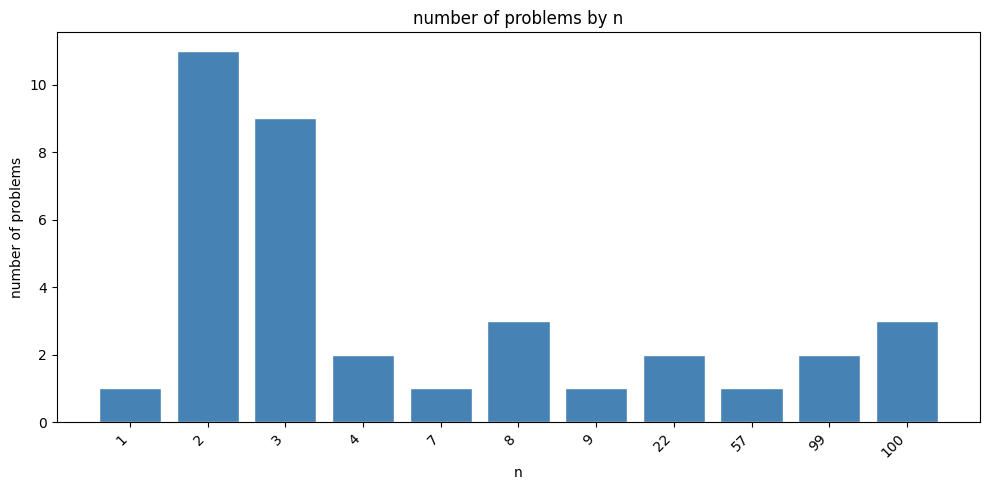

In [95]:
from collections import Counter 
import matplotlib.pyplot as plt

def count_problems_by_n(filepath: str) -> None:
    counter = Counter()
 
    with open(filepath) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split('|')
            if len(parts) < 4:
                continue
            try:
                n = int(parts[3].strip())
                counter[n] += 1
            except ValueError:
                continue  # skip header or malformed lines
 
    print(f"{'n':>6} {'num_problems':>12}")
    print("-" * 20)
    for n in sorted(counter):
        print(f"{n:>6} {counter[n]:>12}")
 
    ns = sorted(counter)
    counts = [counter[n] for n in ns]
 
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar([str(n) for n in ns], counts, color="steelblue", edgecolor="white")
    ax.set_xlabel("n")
    ax.set_ylabel("number of problems")
    ax.set_title("number of problems by n")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

count_problems_by_n("hyperparam_tuning/cutest_problem_selection_hyperparam_tuning.txt")

# Algorithm Wrappers

In [ ]:
def gps_expl_best_val_batch_constrained(problem_idx, num_cpus, k, delta, tao, n_batch_calls_limit):
    GPS_expl_k_fail_wrapper = BB_wrapper.BB_k_fail_wrapper(cutest_wrapper.problem_functions[problem_idx], k*torch.ones((1024, 2), dtype=torch.int16), num_cpus)
    alg = k_fail_GPS.GPS_k_fail(torch.from_numpy(cutest_wrapper.problems[problem_idx].x0), GPS_expl_k_fail_wrapper, delta, tao, prediction_software=k_fail_prediction.constant_prediction_software(k), log_file_path=f"alg_logs/GPS/hyperparam_tuning_{problem_idx}_{delta:.2f}_{tao:.2f}_expl_gps.txt") # exploitation and utilisation are true by default

    alg.log_current(message=f"k={k}")
    
    while alg.n_batch_calls < n_batch_calls_limit:
        alg.step_default(random_rotate=True)
    
    # return best function value so far
    return alg.cur_f_val

In [ ]:
def mbtr_expl_best_val_batch_constrained(problem_idx, num_cpus, k, delta, mu, eta, gamma, eps_stop, opportunistic_cpu_exploitation_manual_point_limit, preferred_model_order, n_batch_calls_limit): # eps stop also should be searched for because it is responsible for not wasting function calls, the algorithm knows when a solution is good
    MBTR_expl_k_fail_wrapper = BB_wrapper.BB_k_fail_wrapper(cutest_wrapper.problem_functions[problem_idx], k*torch.ones((1024, 2), dtype=torch.int16), num_cpus)

    alg = k_fail_MBTR.MBTR_k_fail(torch.from_numpy(cutest_wrapper.problems[problem_idx].x0), MBTR_expl_k_fail_wrapper, delta, mu, eta, gamma, eps_stop, prediction_software=k_fail_prediction.constant_prediction_software(k), log_file_path=f"alg_logs/MBTR/hyperparam_tuning_{problem_idx}_{delta:.2f}_{mu:.2f}_{eta:.2f}_{gamma:.2f}_{eps_stop:.2f}_{preferred_model_order}_{opportunistic_cpu_exploitation_manual_point_limit}_expl_mbtr.txt",
                                  preferred_model_order=preferred_model_order, # cpu exploitation is on by default
                                  opportunistic_cpu_exploitation_manual_point_limit=opportunistic_cpu_exploitation_manual_point_limit)
    
    alg.log_current()

    while alg.n_batch_calls < n_batch_calls_limit:
        alg.step_default()
    
    # return best function value so far
    return alg.cur_f_val

# Possible Values and GS

In [ ]:
# general
# number of cpus will be determined for each problem manually
num_cpus_dim_brackets = [
    [4, 4], # n < 4 -> 4 cpus
    [8, 8],
    [16, 16],
    [32, 32],
    [64, 64],
    [128, 128],
]
k_ratios = [ # portion of cpus failing, will be rounded up
    0.05,
    0.1,
    0.2,
]

# GPS
gps_delta_values = [
    0.001,
    0.1,
    0.2,
    0.3,
    0.5,
    1.0,
    1.5,
    2.0,
    3.0,
    4.0,
]
gps_tao_values = [
    0.0001,
    0.01,
    0.05,
    0.1,
    0.2,
    0.3,
    0.5,
    0.75,
    0.9,
    0.99,
]

# MBTR
mbtr_delta_values = [
    0.1,
    1.0,
    2.0,
]

mbtr_mu_values = [
    0.05,
    0.1,
    0.5,
    1.5,
]

mbtr_eta_values = [
    0.1,
    0.5,
    0.9,
]

mbtr_gamma_values = [
    0.1,
    0.5,
    0.9,
]

mbtr_eps_stop_values = [
    0.05,
    0.1,
    0.5,
    1.0,
    4.0,
]

mbtr_preferred_model_order_values = [
    1,
    2,
]

mbtr_opportunistic_cpu_exploitation_manual_point_limit = [
    100,
    200,
    400,
]

In [118]:
from IPython.display import clear_output
from tqdm.notebook import tqdm
import math

# GPS

In [ ]:
gps_achieved_function_vals = torch.ones((cap_n_problems, len(k_ratios), len(gps_delta_values), len(gps_tao_values))) * torch.inf

pbar = tqdm(total=cap_n_problems * len(k_ratios) * len(gps_delta_values) * len(gps_tao_values))

for problem_idx in range(cap_n_problems):
    for k_ratio_idx in range(len(k_ratios)):
        for gps_delta_value_idx in range(len(gps_delta_values)):
            for gps_tao_value_idx in range(len(gps_tao_values)):
                problem_n = cutest_wrapper.problems[problem_idx].n

                num_cpus = num_cpus_dim_brackets[0][1]
                for dim, cpus in num_cpus_dim_brackets:
                    num_cpus = cpus
                    if dim > problem_n:
                        break
                
                k = math.ceil(num_cpus * k_ratios[k_ratio_idx])

                n_batch_limit = 100

                f_val = gps_expl_best_val_batch_constrained(problem_idx, num_cpus, k, gps_delta_values[gps_delta_value_idx], gps_tao_values[gps_tao_value_idx], n_batch_limit)

                gps_achieved_function_vals[problem_idx, k_ratio_idx, gps_delta_value_idx, gps_tao_value_idx] = f_val

                clear_output(wait=True)
                pbar.update(1)

pbar.close()

  0%|          | 0/10800 [00:00<?, ?it/s]

In [120]:
torch.save(gps_achieved_function_vals, 'hyperparam_tuning/gps_achieved_function_vals.pt')

In [121]:
gps_achieved_function_vals = torch.load('hyperparam_tuning/gps_achieved_function_vals.pt')

In [122]:
gps_min_vals_combination_counter = torch.zeros((len(gps_delta_values), len(gps_tao_values)))
acc_threshold = 0.98

for problem_idx in range(cap_n_problems):
    for k_ratio_idx in range(len(k_ratios)):
        current_problem_with_k = gps_achieved_function_vals[problem_idx, k_ratio_idx]

        f_0 = cutest_wrapper.problem_functions[problem_idx](torch.from_numpy(cutest_wrapper.problems[problem_idx].x0))
        
        f_star = torch.min(current_problem_with_k)
        
        f_acc = (f_0 - current_problem_with_k) / (f_0 - f_star)
        
        gps_min_vals_combination_counter += torch.where(f_acc >= acc_threshold, 1, 0)

In [124]:
gps_min_vals_combination_counter

tensor([[63., 73., 74., 75., 72., 72., 66., 69., 70., 60.],
        [70., 73., 74., 78., 74., 78., 78., 77., 70., 69.],
        [64., 71., 75., 75., 78., 81., 74., 73., 78., 71.],
        [63., 73., 70., 70., 76., 76., 72., 77., 74., 74.],
        [69., 76., 78., 81., 76., 76., 80., 76., 76., 66.],
        [66., 77., 78., 81., 82., 78., 81., 82., 79., 79.],
        [69., 72., 75., 75., 72., 75., 74., 77., 78., 68.],
        [65., 72., 75., 75., 75., 74., 82., 77., 75., 72.],
        [62., 76., 75., 75., 76., 75., 76., 73., 79., 66.],
        [64., 75., 76., 76., 78., 76., 77., 80., 70., 73.]])

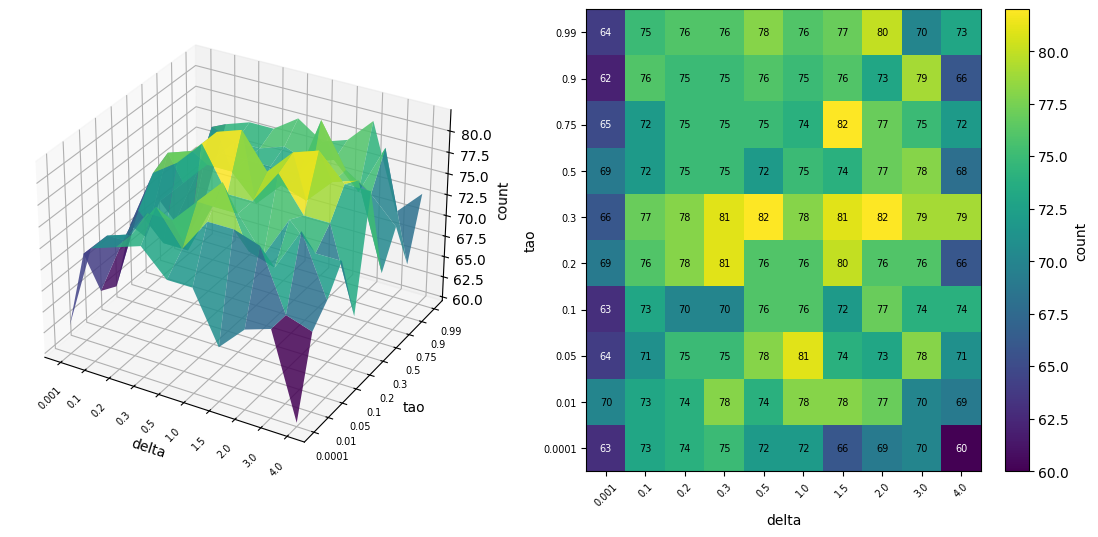

In [130]:
import numpy as np
import matplotlib.pyplot as plt

data = gps_min_vals_combination_counter.numpy()
rows, cols = data.shape

x_pos, y_pos = np.meshgrid(np.arange(cols), np.arange(rows))

fig = plt.figure(figsize=(14, 6))

ax3d = fig.add_subplot(121, projection='3d')
ax3d.plot_surface(x_pos, y_pos, data, cmap='viridis', alpha=0.85)
ax3d.set_xlabel('delta')
ax3d.set_ylabel('tao')
ax3d.set_zlabel('count')
ax3d.set_xticks(np.arange(cols))
ax3d.set_xticklabels(gps_delta_values, rotation=45, fontsize=7)
ax3d.set_yticks(np.arange(rows))
ax3d.set_yticklabels(gps_tao_values, fontsize=7)

ax2d = fig.add_subplot(122)
im = ax2d.imshow(data, cmap='viridis', aspect='auto', origin='lower')
fig.colorbar(im, ax=ax2d, label='count')
ax2d.set_xlabel('delta')
ax2d.set_ylabel('tao')
ax2d.set_xticks(np.arange(cols))
ax2d.set_xticklabels(gps_delta_values, rotation=45, fontsize=7)
ax2d.set_yticks(np.arange(rows))
ax2d.set_yticklabels(gps_tao_values, fontsize=7)

for i in range(rows):
    for j in range(cols):
        color = 'white' if data[i, j] < data.max() * 0.8 else 'black'
        ax2d.text(j, i, int(data[i, j]), ha='center', va='center', fontsize=7, color=color)

plt.show()

# MBTR

In [ ]:
mbtr_delta_values
mbtr_mu_values
mbtr_eta_values
mbtr_gamma_values
mbtr_eps_stop_values
mbtr_preferred_model_order_values
mbtr_opportunistic_cpu_exploitation_manual_point_limit


mbtr_achieved_function_vals = torch.ones((cap_n_problems, len(k_ratios), len(mbtr_delta_values), len(mbtr_mu_values), len(mbtr_eta_values), len(mbtr_gamma_values), len(mbtr_eps_stop_values), len(mbtr_preferred_model_order_values), len(mbtr_opportunistic_cpu_exploitation_manual_point_limit))) * torch.inf

pbar = tqdm(cap_n_problems * len(k_ratios) * len(mbtr_delta_values) * len(mbtr_mu_values) * len(mbtr_eta_values) * len(mbtr_gamma_values) * len(mbtr_eps_stop_values) * len(mbtr_preferred_model_order_values) * len(mbtr_opportunistic_cpu_exploitation_manual_point_limit))

for problem_idx in range(cap_n_problems):
    for k_ratio_idx in range(len(k_ratios)):
        for mbtr_delta_value_idx in range(len(mbtr_delta_values)):
            for mbtr_mu_value_idx in range(len(mbtr_mu_values)):
                for mbtr_eta_value_idx in range(len(mbtr_eta_values)):
                    for mbtr_gamma_value_idx in range(len(mbtr_gamma_values)):
                        for mbtr_eps_stop_value_idx in range(len(mbtr_eps_stop_values)):
                            for mbtr_preferred_model_order_value_idx in range(len(mbtr_preferred_model_order_values)):
                                for mbtr_opportunistic_cpu_exploitation_manual_point_limit_idx in range(len(mbtr_opportunistic_cpu_exploitation_manual_point_limit)):
                                    problem_n = cutest_wrapper.problems[problem_idx].n

                                    num_cpus = num_cpus_dim_brackets[0][1]
                                    for dim, cpus in num_cpus_dim_brackets:
                                        num_cpus = cpus
                                        if dim > problem_n:
                                            break
                                    
                                    k = math.ceil(num_cpus * k_ratios[k_ratio_idx])

                                    n_batch_limit = 100

                                    f_val = mbtr_expl_best_val_batch_constrained(problem_idx, num_cpus, k, mbtr_delta_values[mbtr_delta_value_idx], mbtr_mu_values[mbtr_mu_value_idx], mbtr_eta_values[mbtr_eta_value_idx], mbtr_gamma_values[mbtr_gamma_value_idx], mbtr_eps_stop_values[mbtr_eps_stop_value_idx], mbtr_opportunistic_cpu_exploitation_manual_point_limit[mbtr_opportunistic_cpu_exploitation_manual_point_limit_idx], mbtr_preferred_model_order_values[mbtr_preferred_model_order_value_idx], n_batch_limit)

                                    mbtr_achieved_function_vals[problem_idx, k_ratio_idx, mbtr_delta_value_idx, mbtr_mu_value_idx, mbtr_eta_value_idx, mbtr_gamma_value_idx, mbtr_eps_stop_value_idx, mbtr_opportunistic_cpu_exploitation_manual_point_limit_idx, mbtr_preferred_model_order_value_idx] = f_val

                                    clear_output(wait=True)
                                    pbar.update(1)

pbar.close()

  0%|          | 0/10800 [00:00<?, ?it/s]

In [ ]:
torch.save(mbtr_achieved_function_vals, 'hyperparam_tuning/mbtr_achieved_function_vals.pt')

In [ ]:
mbtr_achieved_function_vals = torch.load('hyperparam_tuning/mbtr_achieved_function_vals.pt')

In [ ]:
mbtr_min_vals_combination_counter = torch.zeros((len(mbtr_delta_values), len(mbtr_mu_values), len(mbtr_eta_values), len(mbtr_gamma_values), len(mbtr_eps_stop_values), len(mbtr_preferred_model_order_values), len(mbtr_opportunistic_cpu_exploitation_manual_point_limit)))
acc_threshold = 0.98

for problem_idx in range(cap_n_problems):
    for k_ratio_idx in range(len(k_ratios)):
        current_problem_with_k = mbtr_achieved_function_vals[problem_idx, k_ratio_idx]

        f_0 = cutest_wrapper.problem_functions[problem_idx](torch.from_numpy(cutest_wrapper.problems[problem_idx].x0))
        
        f_star = torch.min(current_problem_with_k)
        
        f_acc = (f_0 - current_problem_with_k) / (f_0 - f_star)
        
        mbtr_min_vals_combination_counter += torch.where(f_acc >= acc_threshold, 1, 0)

In [ ]:
mbtr_min_vals_combination_counter

tensor([[63., 73., 74., 75., 72., 72., 66., 69., 70., 60.],
        [70., 73., 74., 78., 74., 78., 78., 77., 70., 69.],
        [64., 71., 75., 75., 78., 81., 74., 73., 78., 71.],
        [63., 73., 70., 70., 76., 76., 72., 77., 74., 74.],
        [69., 76., 78., 81., 76., 76., 80., 76., 76., 66.],
        [66., 77., 78., 81., 82., 78., 81., 82., 79., 79.],
        [69., 72., 75., 75., 72., 75., 74., 77., 78., 68.],
        [65., 72., 75., 75., 75., 74., 82., 77., 75., 72.],
        [62., 76., 75., 75., 76., 75., 76., 73., 79., 66.],
        [64., 75., 76., 76., 78., 76., 77., 80., 70., 73.]])

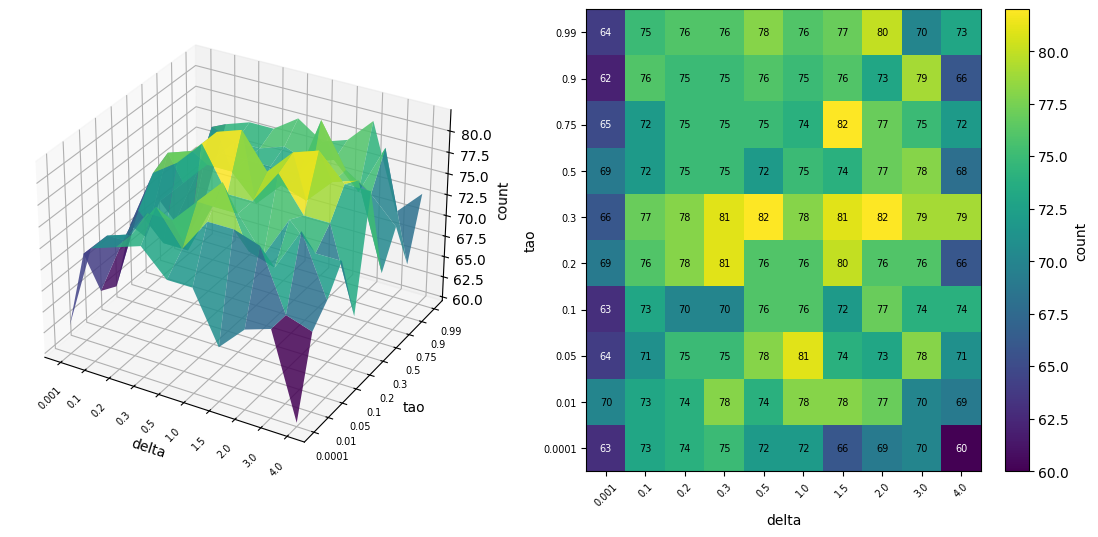

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

data = gps_min_vals_combination_counter.numpy()
rows, cols = data.shape

x_pos, y_pos = np.meshgrid(np.arange(cols), np.arange(rows))

fig = plt.figure(figsize=(14, 6))

ax3d = fig.add_subplot(121, projection='3d')
ax3d.plot_surface(x_pos, y_pos, data, cmap='viridis', alpha=0.85)
ax3d.set_xlabel('delta')
ax3d.set_ylabel('tao')
ax3d.set_zlabel('count')
ax3d.set_xticks(np.arange(cols))
ax3d.set_xticklabels(gps_delta_values, rotation=45, fontsize=7)
ax3d.set_yticks(np.arange(rows))
ax3d.set_yticklabels(gps_tao_values, fontsize=7)

ax2d = fig.add_subplot(122)
im = ax2d.imshow(data, cmap='viridis', aspect='auto', origin='lower')
fig.colorbar(im, ax=ax2d, label='count')
ax2d.set_xlabel('delta')
ax2d.set_ylabel('tao')
ax2d.set_xticks(np.arange(cols))
ax2d.set_xticklabels(gps_delta_values, rotation=45, fontsize=7)
ax2d.set_yticks(np.arange(rows))
ax2d.set_yticklabels(gps_tao_values, fontsize=7)

for i in range(rows):
    for j in range(cols):
        color = 'white' if data[i, j] < data.max() * 0.8 else 'black'
        ax2d.text(j, i, int(data[i, j]), ha='center', va='center', fontsize=7, color=color)

plt.show()

In [31]:
print(cutest_wrapper.problems[8].bl)
print(cutest_wrapper.problems[8].bu)

[-1.e+20 -1.e+20 -1.e+20 -1.e+20 -1.e+20 -1.e+20]
[1.e+20 1.e+20 1.e+20 1.e+20 1.e+20 1.e+20]


In [62]:
torch.count_nonzero(gps_achieved_function_vals <= -1e20)

tensor(298)

In [67]:
for problem_idx in range(cap_n_problems):
    if torch.any(gps_achieved_function_vals[problem_idx] <= -1e20):
        print(f"problem idx: {problem_idx} gets <= -1e20")

problem idx: 6 gets <= -1e20
problem idx: 8 gets <= -1e20
problem idx: 11 gets <= -1e20
problem idx: 20 gets <= -1e20


In [40]:
gps_achieved_function_vals.numel()

7680

In [49]:
cutest_wrapper.problems[8].name

'LANCZOS3LS'

In [47]:
cutest_wrapper.problem_functions[8](torch.tensor([-550.4365687173092, -765.5429413402337, 791.3652695819852, -1980.7657997225178, 1576.2005548412562, -429.914772294322]))

nan

In [51]:
import pycutest

pycutest.print_available_sif_params("LANCZOS3LS")

Parameters available for problem LANCZOS3LS:
End of parameters for problem LANCZOS3LS


In [55]:
import numpy as np

cutest_wrapper.problems[8].obj(np.array([-550.4365687173092, -765.5429413402337, 791.3652695819852, -1980.7657997225178, 1576.2005548412562, -429.914772294322]))

nan

In [58]:
torch.cat((gps_achieved_function_vals[:8], gps_achieved_function_vals[9:]))

tensor([[[[4.9488e-05, 7.1531e-32, 1.4013e-45,  ..., 0.0000e+00,
           0.0000e+00, 2.0280e-14],
          [4.9259e-04, 1.4834e-30, 1.4013e-45,  ..., 0.0000e+00,
           0.0000e+00, 1.4604e-16],
          [7.2881e-13, 2.1353e-22, 1.4013e-45,  ..., 0.0000e+00,
           0.0000e+00, 1.0163e-17],
          ...,
          [7.7492e-09, 7.8291e-31, 1.4013e-45,  ..., 0.0000e+00,
           0.0000e+00, 7.5235e-14],
          [3.0886e-05, 2.7799e-28, 0.0000e+00,  ..., 0.0000e+00,
           0.0000e+00, 3.1470e-10],
          [8.4860e-06, 1.3484e-39, 0.0000e+00,  ..., 0.0000e+00,
           0.0000e+00, 3.0360e-11]],

         [[5.1116e-07, 5.9128e-32, 1.4013e-45,  ..., 0.0000e+00,
           0.0000e+00, 2.0280e-14],
          [6.3418e-04, 4.4574e-32, 1.4013e-45,  ..., 0.0000e+00,
           0.0000e+00, 2.9628e-16],
          [7.4528e-13, 1.6414e-20, 1.4013e-45,  ..., 0.0000e+00,
           0.0000e+00, 1.0163e-17],
          ...,
          [9.4821e-09, 2.4918e-30, 1.4013e-45,  ..., 0.0000